<a href="https://colab.research.google.com/github/TareKelKhateb/Home_Credit_Default/blob/main/Home_Credit_Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

# This pulls the values from that sidebar you just set up
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

import kagglehub

# Download latest version
path = kagglehub.competition_download('home-credit-default-risk')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/home-credit-default-risk


In [ ]:
import pandas as pd
# get an explanation of a column
columns_info = pd.read_csv(path + '/HomeCredit_columns_description.csv', encoding='latin1')
def get_column_explanation(column_name):
    column_info = columns_info[columns_info['Row'] == column_name]
    return column_info['Description'].values[0] if not column_info.empty else "Column not found"

# test
get_column_explanation('AMT_CREDIT_MAX_OVERDUE')

'Maximal amount overdue on the Credit Bureau credit so far (at application date of loan in our sample)'

scratch pad :
today we are focusing on application train and trying to build a model using it
now ....


1.   XNA/UNKOWN in categorical columns needs to be replaced with nan olso  
2.   DAYS_EMPLOYED 	count
DAYS_EMPLOYED
365243	55374
3.   there is alot of highly correlated features that gives the same signal
we could leave it to cat boost to remove them logically or drop them
4. numerical columns' values for some z scores are too big which is okay to deal with as long as we are using a tree model


5. we need information by grouping some the extra features in the other table
6. join bureau_balnce -> bureau with feature engineering

7. join bureau -> main table with feature engineering


8. we need  to the prepressoning(joining) for test data, note: that joining every time is consuming if we are using a pipeline so the script will merge train and test then split again

9. join the rest of the tables (agg)

-------------------- not Done-------------------------


10. feature engineering of the top features (check discussion for more )




In [ ]:
import pandas as pd

df = pd.read_csv(path + '/application_train.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_test = pd.read_csv(path + '/application_test.csv')
# concat both to df_full and keep target = nan in test_concat
df_full = pd.concat([df, df_test], axis=0, ignore_index=True)
df_full["TARGET"].isnull()

,TARGET
0,False
1,False
2,False
3,False
4,False
...,...
356250,True
356251,True
356252,True
356253,True


In [ ]:
df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [ ]:
# Missing values summary (top 10 columns by % missing)
missing_pct = df.isnull().mean() * 100
print("\nTop 10 columns by missing %:\n", missing_pct.sort_values(ascending=False).head(10))



Top 10 columns by missing %:
 COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64


In [ ]:
print(df.shape)

(307511, 122)


In [ ]:
import pandas as pd
import numpy as np

# 1. Basic Info & Memory Usage
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Memory Usage ---")
df.info(verbose=False) # verbose=False gives a clean summary

# 2. Check for Missing Values (The "Insane" NaNs)
missing = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing, missing_percent], axis=1)
missing_table.columns = ['Total Missing', '% of Total Values']
# Only show columns with missing values, sorted descending
missing_table = missing_table[missing_table['Total Missing'] > 0].sort_values('% of Total Values', ascending=False)

print("\n--- Top 10 Missing Columns ---")
print(missing_table.head(10))

# 3. Separate Features by Type (Essential for CatBoost)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print(f"\nCategorical Columns ({len(cat_cols)}): {cat_cols[:5]}...") # Just shows first 5
print(f"Numerical Columns ({len(num_cols)}): {num_cols[:5]}...")

# 4. Check the Target Balance (CRITICAL for this competition)
print("\n--- Target Distribution (0: Repaid, 1: Default) ---")
print(df['TARGET'].value_counts(normalize=True))

# 5. Quick look at the 'Magic Numbers'
print("\n--- Summary of DAYS_EMPLOYED (Check for 365243) ---")
print(df['DAYS_EMPLOYED'].describe())

--- Dataset Shape ---
(307511, 122)

--- Memory Usage ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB

--- Top 10 Missing Columns ---
                          Total Missing  % of Total Values
COMMONAREA_MEDI                  214865          69.872297
COMMONAREA_MODE                  214865          69.872297
COMMONAREA_AVG                   214865          69.872297
NONLIVINGAPARTMENTS_MODE         213514          69.432963
NONLIVINGAPARTMENTS_MEDI         213514          69.432963
NONLIVINGAPARTMENTS_AVG          213514          69.432963
FONDKAPREMONT_MODE               210295          68.386172
LIVINGAPARTMENTS_AVG             210199          68.354953
LIVINGAPARTMENTS_MEDI            210199          68.354953
LIVINGAPARTMENTS_MODE            210199          68.354953

Categorical Columns (16): ['NAME_CONTRACT_TYPE', 'CO

In [ ]:
# Create a summary table of the stats
stats = df.describe().T  # Transpose to make it 122 rows x 8 columns

# 1. Identify "Magic Number" candidates (where Max is way higher than Median)
stats['Anomaly_Score'] = stats['max'] / stats['50%']

# 2. Filter for columns that look suspicious (very high max values)
suspicious_cols = stats[stats['max'] > 100000].sort_values('max', ascending=False)

print("--- Potential Magic Numbers / Outliers ---")
print(suspicious_cols[['min', '50%', 'max', 'Anomaly_Score']])

# 3. Check for "Constant" columns (features that have the same value for everyone)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"\n--- Constant Columns (Zero Info): {constant_cols} ---")

--- Potential Magic Numbers / Outliers ---
                       min       50%          max  Anomaly_Score
AMT_INCOME_TOTAL   25650.0  147150.0  117000000.0     795.107034
AMT_CREDIT         45000.0  513531.0    4050000.0       7.886574
AMT_GOODS_PRICE    40500.0  450000.0    4050000.0       9.000000
SK_ID_CURR        100002.0  278202.0     456255.0       1.640013
DAYS_EMPLOYED     -17912.0   -1213.0     365243.0    -301.107172
AMT_ANNUITY         1615.5   24903.0     258025.5      10.361222

--- Constant Columns (Zero Info): [] ---


In [ ]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Checking {len(cat_cols)} categorical columns...\n")
print("-" * 30)

for col in cat_cols:
    n_unique = df[col].nunique()
    nans = df[col].isnull().sum()
    nan_pct = (nans / len(df)) * 100

    print(f"COLUMN: {col}")
    print(f"Unique Values: {n_unique} | Missing: {nans} ({nan_pct:.2f}%)")

    # value_counts(dropna=False) lets you see if 'NaN' is a major category
    print(df[col].value_counts(dropna=False))
    print("-" * 30)

Checking 16 categorical columns...

------------------------------
COLUMN: NAME_CONTRACT_TYPE
Unique Values: 2 | Missing: 0 (0.00%)
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
------------------------------
COLUMN: CODE_GENDER
Unique Values: 3 | Missing: 0 (0.00%)
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
------------------------------
COLUMN: FLAG_OWN_CAR
Unique Values: 2 | Missing: 0 (0.00%)
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
------------------------------
COLUMN: FLAG_OWN_REALTY
Unique Values: 2 | Missing: 0 (0.00%)
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
------------------------------
COLUMN: NAME_TYPE_SUITE
Unique Values: 7 | Missing: 1292 (0.42%)
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               

In [ ]:
df["DAYS_EMPLOYED"].value_counts()

,count
DAYS_EMPLOYED,
365243,55374
-200,156
-224,152
-199,151
-230,151
...,...
-11707,1
-13385,1
-9985,1


In [ ]:
# Calculate correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
high_correlated_colums_to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"Highly correlated columns to consider dropping: {len(high_correlated_colums_to_drop)}")
print(high_correlated_colums_to_drop)

Highly correlated columns to consider dropping: 35
['AMT_GOODS_PRICE', 'FLAG_EMP_PHONE', 'REGION_RATING_CLIENT_W_CITY', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE', 'OBS_60_CNT_SOCIAL_CIRCLE']


In [ ]:
import pandas as pd

# 1. Identify anomalies (Your logic, but refined into a summary table)
anomaly_data = []

for col in df.select_dtypes(include=[np.number]).columns:
    mu = df[col].mean()
    std = df[col].std()
    max_val = df[col].max()

    if std > 0:
        z_score = (max_val - mu) / std
        if z_score > 10:  # The "10-Sigma" threshold
            anomaly_data.append({
                'Column': col,
                'Mean': round(mu, 2),
                'Max': round(max_val, 2),
                'Z-Score': round(z_score, 2),
                '50% (Median)': round(df[col].median(), 2)
            })

# 2. Display as a clean Table
anomaly_report = pd.DataFrame(anomaly_data).sort_values(by='Z-Score', ascending=False)
print("--- Detailed Anomaly Report ---")
print(anomaly_report)

# 3. Deep Dive into the Top Anomaly (Example: DAYS_EMPLOYED)
# Let's see the actual counts of these extreme values
for col in anomaly_report['Column'].head(5): # Check top 5 most suspicious
    print(f"\nValue Distribution for {col}:")
    print(df[col].value_counts().sort_index(ascending=False).head(5))

--- Detailed Anomaly Report ---
                        Column       Mean          Max  Z-Score  50% (Median)
1             AMT_INCOME_TOTAL  168797.92  117000000.0   492.70     147150.00
29            FLAG_DOCUMENT_12       0.00          1.0   392.11          0.00
42   AMT_REQ_CREDIT_BUREAU_QRT       0.27        261.0   328.36          0.00
27            FLAG_DOCUMENT_10       0.00          1.0   209.59          0.00
23             FLAG_DOCUMENT_2       0.00          1.0   153.80          0.00
19    OBS_30_CNT_SOCIAL_CIRCLE       1.42        348.0   144.35          0.00
21    OBS_60_CNT_SOCIAL_CIRCLE       1.41        344.0   143.96          0.00
24             FLAG_DOCUMENT_4       0.00          1.0   110.90          0.00
39   AMT_REQ_CREDIT_BUREAU_DAY       0.01          9.0    81.20          0.00
20    DEF_30_CNT_SOCIAL_CIRCLE       0.14         34.0    75.79          0.00
25             FLAG_DOCUMENT_7       0.00          1.0    72.19          0.00
22    DEF_60_CNT_SOCIAL_CIRCLE  

### aggregation from other tables




#### bureau_balance ->bureua

In [ ]:
bureau_balance = pd.read_csv(path + '/bureau_balance.csv')
bureau = pd.read_csv(path + '/bureau.csv')

In [ ]:
bureau_balance["STATUS"].value_counts()

,count
STATUS,
C,13646993
0,7499507
X,5810482
1,242347
5,62406
2,23419
3,8924
4,5847


In [ ]:
bureau.shape

(1716428, 17)

In [ ]:

# 1. One-Hot Encoding the Status
# This creates columns like STATUS_0, STATUS_1, STATUS_C, etc.
bb_processed = pd.get_dummies(bureau_balance, columns=['STATUS'], prefix='STATUS')

# 2. Defining Windows
# We use MONTHS_BALANCE (e.g., -3, -6, -12)
# Remember: -3 is the LAST 3 months.
windows = [3, 6, 12]
status_cols = [col for col in bb_processed.columns if 'STATUS_' in col]

# 3. Last Status Trend (The most recent month's status)
# We sort by ID and Month, then take the last record
bb_processed = bb_processed.sort_values(['SK_ID_BUREAU', 'MONTHS_BALANCE'])
last_status = bb_processed.groupby('SK_ID_BUREAU')[status_cols].last().add_suffix('_LAST')

# 4. Main Aggregation
# Base aggregations: Age of loan and total counts
agg_results = bb_processed.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],  # Min is the "Age", Size is the "Duration"
})
# Flatten columns: 'MONTHS_BALANCE_min', etc.
agg_results.columns = ['_'.join(col).strip() for col in agg_results.columns.values]

# 5. Summing the One-Hot Statuses (Total History)
total_status_sums = bb_processed.groupby('SK_ID_BUREAU')[status_cols].sum()
agg_results = agg_results.join(total_status_sums)

# 6. Windowed Aggregations (Last 3, 6, 12 months)
for w in windows:
    # Filter for the window, then sum the statuses
    window_sum = bb_processed[bb_processed['MONTHS_BALANCE'] >= -w].groupby('SK_ID_BUREAU')[status_cols].sum()
    agg_results = agg_results.join(window_sum.add_suffix(f'_LAST_{w}M'))

# 7. Join the Last Status Trend
agg_results = agg_results.join(last_status)

# 8. FINAL STEP: Merge into Bureau
bureau = bureau.merge(agg_results, on='SK_ID_BUREAU', how='left')

print(f"Bureau shape after join: {bureau.shape}")

Bureau shape after join: (1716428, 60)


#### bureau --> main table

Credit history depth

**Count of total bureau credits per applicant**
DAYS_CREDIT min/max/mean — how long ago their oldest and most recent credits were opened
Count of credits opened in last 1 year, 2 years (recent credit-seeking behavior)

**Current debt burden**

**Count of credits where DAYS_ENDDATE_FACT is null → still active credits**
Sum/count of active credits (open load right now)
DAYS_CREDIT_ENDDATE mean for active credits — how far until they're expected to close

Overdue behavior — most predictive

**Max CREDIT_DAY_OVERDUE across all bureau entries**
Count of entries where CREDIT_DAY_OVERDUE > 0
Any entry with CREDIT_DAY_OVERDUE > 60 or > 90 (binary flag) — these are serious delinquencies
Mean CREDIT_DAY_OVERDUE (but max is usually stronger)

Credit closure pattern
**bold text**
DAYS_ENDDATE_FACT - DAYS_CREDIT_ENDDATE → closed early (negative = early, positive = late). Late closure is a risk signal.
Count of credits closed late vs on time
Count of credits where DAYS_CREDIT_ENDDATE is already past (negative) but credit is still open — currently overrunning their schedule





In [ ]:
original_bureau = bureau.iloc[:,:16]

In [ ]:
original_bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02


In [ ]:

print(get_column_explanation('CNT_CREDIT_PROLONG'))

How many times was the Credit Bureau credit prolonged


In [ ]:
original_bureau.head(5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21


In [ ]:
# get value counts for categorical data in original_bureau
cat_cols = original_bureau.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\nValue Counts for {col}:")
    print(original_bureau[col].value_counts())
    print("-" * 30)


Value Counts for CREDIT_ACTIVE:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64
------------------------------

Value Counts for CREDIT_CURRENCY:
CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64
------------------------------

Value Counts for CREDIT_TYPE:
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan 

In [ ]:
# get the percentage of nulls for each columns
missing_pct = original_bureau.isnull().mean()
print("\nPercentage of Missing Values:\n", missing_pct.sort_values(ascending=False))



Percentage of Missing Values:
 AMT_CREDIT_MAX_OVERDUE    0.655133
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_DEBT       0.150119
DAYS_CREDIT_ENDDATE       0.061496
AMT_CREDIT_SUM            0.000008
SK_ID_CURR                0.000000
SK_ID_BUREAU              0.000000
DAYS_CREDIT               0.000000
CREDIT_DAY_OVERDUE        0.000000
CREDIT_ACTIVE             0.000000
CREDIT_CURRENCY           0.000000
CNT_CREDIT_PROLONG        0.000000
AMT_CREDIT_SUM_OVERDUE    0.000000
CREDIT_TYPE               0.000000
DAYS_CREDIT_UPDATE        0.000000
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import gc

print(f"Starting shape of df: {df.shape}")

# ==========================================
# STEP 1: Row-Level Feature Engineering (Before Grouping)
# ==========================================
# 1. Debt-to-Credit Ratio (Handle division by zero safely)
bureau['DEBT_CREDIT_RATIO'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM'].replace(0, np.nan)

# 2. Closed Late Flag (Positive = closed after expected end date)
diff = bureau['DAYS_ENDDATE_FACT'] - bureau['DAYS_CREDIT_ENDDATE']
bureau['CLOSED_LATE_FLAG'] = np.where(diff.isna(), np.nan, (diff > 0).astype(float))


# 3. Active Loan Flag (If FACT end date is null, the loan is still active)
bureau['IS_ACTIVE_FLAG'] = bureau['DAYS_ENDDATE_FACT'].isnull().astype(int)

# 4. Severe Overdue Flag (> 60 days)
bureau['SEVERE_OVERDUE_FLAG'] = (bureau['CREDIT_DAY_OVERDUE'] > 60).astype(int)

# 5. One-Hot Encode Categoricals (Like CREDIT_TYPE and CREDIT_ACTIVE)
bureau = pd.get_dummies(bureau, columns=['CREDIT_TYPE', 'CREDIT_ACTIVE'])

# 6. How recently was this credit opened relative to application?
bureau['DAYS_CREDIT_RECENT'] = (bureau['DAYS_CREDIT'] >= -365).astype(int)

# ==========================================
# STEP 2: The Aggregation Dictionary
# ==========================================
# This tells Pandas exactly how to handle every column.
bureau_agg_dict = {
    # --- The Days & Time ---
    'DAYS_CREDIT': ['min', 'max', 'mean', 'count'], # 'count' gives total bureau credits
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE': ['mean', 'max'],
    'DAYS_CREDIT_RECENT': ['sum'] , # count of credits in last year

    # --- Overdue Behavior ---
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'SEVERE_OVERDUE_FLAG': ['sum'], # How many serious delinquencies?

    # --- The Money (AMT) & Leverage ---
    'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_SUM': ['sum', 'mean', 'max'],
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean', 'max'],
    'AMT_CREDIT_SUM_LIMIT': ['sum', 'mean'],
    'DEBT_CREDIT_RATIO': ['mean', 'max'], # Leverage

    # --- Behavior & Patterns ---
    'CNT_CREDIT_PROLONG': ['sum', 'max'],
    'CLOSED_LATE_FLAG': ['sum', 'mean'],
    'IS_ACTIVE_FLAG': ['sum', 'mean']
}

# --- Dynamic Additions ---
# Automatically find all the One-Hot Encoded columns and bureau_balance status columns
# and add them to the dictionary to be summed and averaged.
dynamic_cols = [col for col in bureau.columns if 'CREDIT_TYPE_' in col or 'CREDIT_ACTIVE_' in col or 'STATUS_' in col]
for col in dynamic_cols:
    bureau_agg_dict[col] = ['sum', 'mean']

# ==========================================
# STEP 3: GroupBy, Flatten, and Merge
# ==========================================
# Group by Applicant ID
bureau_agg = bureau.groupby('SK_ID_CURR').agg(bureau_agg_dict)

# Flatten the multi-level column names (e.g., 'DAYS_CREDIT', 'mean' -> 'BUREAU_DAYS_CREDIT_mean')
bureau_agg.columns = ['BUREAU_' + '_'.join(col).strip() for col in bureau_agg.columns.values]

# Merge into the main application dataframe
df_full = df_full.merge(bureau_agg, on='SK_ID_CURR', how='left')


Starting shape of df: (307511, 122)


In [ ]:

print(f"Final shape of df after Bureau merge: {df_full.shape}")

# ==========================================
# STEP 4: Memory Clean-Up (CRITICAL)
# ==========================================
del bureau, bureau_agg
gc.collect()

Final shape of df after Bureau merge: (356255, 271)


0

In [ ]:
# get the top 10 with nulls from df
missing_pct = df.isnull().mean()
missing_pct.sort_values(ascending=False).head(10)

# count those with more than 65% how many len
len(missing_pct[missing_pct > 0.65])



17

#### installments_payments -> previous_application

In [ ]:
# read installment table
installments_payments = pd.read_csv(path + '/installments_payments.csv')

In [ ]:
installments_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [ ]:
for col in installments_payments.columns:
    print(col,get_column_explanation(col))

SK_ID_PREV Column not found
SK_ID_CURR ID of loan in our sample
NUM_INSTALMENT_VERSION Version of installment calendar (0 is for credit card) of previous credit. Change of installment version from month to month signifies that some parameter of payment calendar has changed
NUM_INSTALMENT_NUMBER On which installment we observe payment
DAYS_INSTALMENT When the installment of previous credit was supposed to be paid (relative to application date of current loan)
DAYS_ENTRY_PAYMENT When was the installments of previous credit paid actually (relative to application date of current loan)
AMT_INSTALMENT What was the prescribed installment amount of previous credit on this installment
AMT_PAYMENT What the client actually paid on previous credit on this installment


In [ ]:
installments_payments.shape

(13605401, 8)

In [ ]:
# Calculate the Time Gaps
# If Entry > Instalment, the result is positive (Days Late)
installments_payments['PAYMENT_DPD'] = (installments_payments['DAYS_ENTRY_PAYMENT'] - installments_payments['DAYS_INSTALMENT']).clip(lower=0)

# If Instalment > Entry, the result is positive (Days Early)
installments_payments['PAYMENT_DBD'] = (installments_payments['DAYS_INSTALMENT'] - installments_payments['DAYS_ENTRY_PAYMENT']).clip(lower=0)

# Calculate the Money Gap
# Positive means they underpaid.
installments_payments['PAYMENT_DIFF'] = installments_payments['AMT_INSTALMENT'] - installments_payments['AMT_PAYMENT']

In [ ]:
# # no need for now
# inst_agg_dict = {
#     'NUM_INSTALMENT_VERSION': ['nunique'],
#     'DPD': ['max', 'mean', 'sum'],
#     'DBD': ['max', 'mean', 'sum'],
#     'PAYMENT_DIFF': ['max', 'mean', 'sum'],
#     'AMT_INSTALMENT': ['max', 'mean', 'sum'],
#     'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
#     'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
# }

# # Rename columns to be clearer (no code, just defining the dictionary logic)
# # We will also add a 'COUNT' of total installments per person.

In [ ]:
# Group by Applicant
inst_agg = installments_payments.groupby('SK_ID_CURR').agg({
    'PAYMENT_DPD': ['max', 'mean', 'sum'],
    'PAYMENT_DBD': ['max', 'mean', 'sum'],
    'PAYMENT_DIFF': ['max', 'mean', 'sum'],
    'AMT_INSTALMENT': ['max', 'mean', 'sum'],
    'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
    'DAYS_ENTRY_PAYMENT': ['size'] # This acts as a 'Count of installments'
})

# Flatten column names (e.g., INSTAL_PAYMENT_DP_max)
inst_agg.columns = ['INSTAL_' + '_'.join(col).strip() for col in inst_agg.columns.values]

# Merge into your main dataframe
df_full = df_full.merge(inst_agg, on='SK_ID_CURR', how='left')

# Memory Management
del installments_payments, inst_agg
gc.collect()

print(f"New df_full shape: {df_full.shape}")

New df_full shape: (356255, 288)


#### POS_CASH_balance --> main table

In [ ]:
# read table pos_cash_balance
pos_cash_balance = pd.read_csv(path + '/POS_CASH_balance.csv')

In [ ]:
pos_cash_balance.head(10)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0
5,2207092,342166,-32,12.0,12.0,Active,0,0
6,1110516,204376,-38,48.0,43.0,Active,0,0
7,1387235,153211,-35,36.0,36.0,Active,0,0
8,1220500,112740,-31,12.0,12.0,Active,0,0
9,2371489,274851,-32,24.0,16.0,Active,0,0


In [ ]:
for col in pos_cash_balance.columns:
    print(col,get_column_explanation(col))

SK_ID_PREV Column not found
SK_ID_CURR ID of loan in our sample
MONTHS_BALANCE Month of balance relative to application date (-1 means the freshest balance date)
CNT_INSTALMENT Term of previous credit (can change over time)
CNT_INSTALMENT_FUTURE Installments left to pay on the previous credit
NAME_CONTRACT_STATUS Contract status during the month
SK_DPD DPD (days past due) during the month of previous credit
SK_DPD_DEF DPD during the month with tolerance (debts with low loan amounts are ignored) of the previous credit


In [ ]:
pos_cash_balance["NAME_CONTRACT_STATUS"].value_counts()

,count
NAME_CONTRACT_STATUS,
Active,9151119
Completed,744883
Signed,87260
Demand,7065
Returned to the store,5461
Approved,4917
Amortized debt,636
Canceled,15
XNA,2


In [ ]:

# 1. Progress Ratio: How much of the loan is remaining?
# (Future installments / Total installments)
# If this is close to 1, the loan is new. If close to 0, it's almost done.
pos_cash_balance['POS_REMAINING_PROGRESS'] = pos_cash_balance['CNT_INSTALMENT_FUTURE'] / pos_cash_balance['CNT_INSTALMENT'].replace(0, np.nan)

# 2. Late Payment Flags
pos_cash_balance['POS_IS_LATE'] = (pos_cash_balance['SK_DPD'] > 0).astype(int)
pos_cash_balance['POS_IS_LATE_WITH_TOLERANCE'] = (pos_cash_balance['SK_DPD_DEF'] > 0).astype(int)

# 3. One-Hot Encode the Contract Status (Active, Completed, etc.)
pos_cash_balance = pd.get_dummies(pos_cash_balance, columns=['NAME_CONTRACT_STATUS'], prefix='POS_STAT')

In [ ]:
# Identify the status columns we just created
status_cols = [col for col in pos_cash_balance.columns if 'POS_STAT_' in col]

pos_agg_dict = {
    'MONTHS_BALANCE': ['max', 'min', 'size'],      # Age and duration of history
    'CNT_INSTALMENT': ['max', 'mean'],             # Size of the loans
    'CNT_INSTALMENT_FUTURE': ['max', 'mean', 'sum'], # Upcoming burden
    'SK_DPD': ['max', 'mean'],                     # Seriousness of delays
    'SK_DPD_DEF': ['max', 'mean'],                 # Delays ignoring small amounts
    'POS_REMAINING_PROGRESS': ['max', 'mean'],     # How far they are in their loans
    'POS_IS_LATE': ['sum', 'mean'],                # Frequency of lateness
    'POS_IS_LATE_WITH_TOLERANCE': ['sum', 'mean']
}

# Add the status columns to the dictionary
for col in status_cols:
    pos_agg_dict[col] = ['mean', 'sum']

In [ ]:
# Group by Applicant
pos_agg = pos_cash_balance.groupby('SK_ID_CURR').agg(pos_agg_dict)

# Flatten column names
pos_agg.columns = ['POS_' + '_'.join(col).strip() for col in pos_agg.columns.values]

# Merge into the main dataframe
df_full = df_full.merge(pos_agg, on='SK_ID_CURR', how='left')

# Memory Management
del pos_cash_balance, pos_agg
gc.collect()

print(f"New df_full shape after POS merge: {df_full.shape}")

New df_full shape after POS merge: (356255, 324)


In [ ]:
# get the top 10 with nulls from df
missing_pct = df_full.isnull().mean()

# count those with more than 65% how many len
len(missing_pct[missing_pct > 0.65])



17

#### credit_card_balance --> main table

In [ ]:
# read table pos_cash_balance
credit_card_balance = pd.read_csv(path + '/credit_card_balance.csv')

In [ ]:
credit_card_balance.shape

(3840312, 23)

In [ ]:
credit_card_balance.head(10)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.500,0.0,877.500,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.000,0.0,0.000,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.000,0.0,0.000,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.000,0.0,0.000,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.000,0.0,11547.000,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0
5,2646502,380010,-7,82903.815,270000,0.0,0.000,0.0,0.000,4449.105,...,82773.315,82773.315,0.0,0,0.0,0.0,2.0,Active,7,0
6,1079071,171320,-6,353451.645,585000,67500.0,67500.000,0.0,0.000,14684.175,...,351881.145,351881.145,1.0,1,0.0,0.0,6.0,Active,0,0
7,2095912,118650,-7,47962.125,45000,45000.0,45000.000,0.0,0.000,0.000,...,47962.125,47962.125,1.0,1,0.0,0.0,51.0,Active,0,0
8,2181852,367360,-4,291543.075,292500,90000.0,289339.425,0.0,199339.425,130.500,...,286831.575,286831.575,3.0,8,0.0,5.0,3.0,Active,0,0
9,1235299,203885,-5,201261.195,225000,76500.0,111026.700,0.0,34526.700,6338.340,...,197224.695,197224.695,3.0,9,0.0,6.0,38.0,Active,0,0


In [ ]:
for col in credit_card_balance.columns:
    print(col,get_column_explanation(col))

SK_ID_PREV Column not found
SK_ID_CURR ID of loan in our sample
MONTHS_BALANCE Month of balance relative to application date (-1 means the freshest balance date)
AMT_BALANCE Balance during the month of previous credit
AMT_CREDIT_LIMIT_ACTUAL Credit card limit during the month of the previous credit
AMT_DRAWINGS_ATM_CURRENT Amount drawing at ATM during the month of the previous credit
AMT_DRAWINGS_CURRENT Amount drawing during the month of the previous credit
AMT_DRAWINGS_OTHER_CURRENT Amount of other drawings during the month of the previous credit
AMT_DRAWINGS_POS_CURRENT Amount drawing or buying goods during the month of the previous credit
AMT_INST_MIN_REGULARITY Minimal installment for this month of the previous credit
AMT_PAYMENT_CURRENT How much did the client pay during the month on the previous credit
AMT_PAYMENT_TOTAL_CURRENT How much did the client pay during the month in total on the previous credit
AMT_RECEIVABLE_PRINCIPAL Amount receivable for principal on the previous cre

In [ ]:
import pandas as pd
import numpy as np
import gc

# 1. Utilization Ratio: How much of the limit are they using?
# (Balance / Limit)
credit_card_balance['CC_UTILIZATION'] = credit_card_balance['AMT_BALANCE'] / credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)

# 2. ATM Drawing Ratio: How much of their spending is "Desperate" Cash?
# (ATM Drawings / Total Drawings)
credit_card_balance['CC_ATM_DRAWING_RATIO'] = credit_card_balance['AMT_DRAWINGS_ATM_CURRENT'] / credit_card_balance['AMT_DRAWINGS_CURRENT'].replace(0, np.nan)

# 3. Payment Ratio: Are they paying more than the required minimum?
# (Payment / Minimum Installment)
# A ratio of 1.0 means they are only paying the bare minimum (Risk signal)
credit_card_balance['CC_PAYMENT_RATIO'] = credit_card_balance['AMT_PAYMENT_CURRENT'] / credit_card_balance['AMT_INST_MIN_REGULARITY'].replace(0, np.nan)

# 4. Late Payment Flags
credit_card_balance['CC_IS_LATE'] = (credit_card_balance['SK_DPD'] > 0).astype(int)

# 5. One-Hot Encode Contract Status
credit_card_balance = pd.get_dummies(credit_card_balance, columns=['NAME_CONTRACT_STATUS'], prefix='CC_STAT')

In [ ]:
cc_agg_dict = {
    'MONTHS_BALANCE': ['max', 'min', 'size'],
    'AMT_BALANCE': ['max', 'mean', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['max', 'mean'],
    'AMT_DRAWINGS_ATM_CURRENT': ['max', 'sum'],
    'AMT_DRAWINGS_CURRENT': ['max', 'sum'],
    'CNT_DRAWINGS_ATM_CURRENT': ['max', 'sum'],
    'CNT_DRAWINGS_CURRENT': ['max', 'sum'],
    'SK_DPD': ['max', 'mean'],
    'CC_UTILIZATION': ['max', 'mean'],
    'CC_ATM_DRAWING_RATIO': ['max', 'mean'],
    'CC_PAYMENT_RATIO': ['max', 'mean'],
    'CC_IS_LATE': ['sum', 'mean']
}

# Automatically add the Status columns
status_cols = [col for col in credit_card_balance.columns if 'CC_STAT_' in col]
for col in status_cols:
    cc_agg_dict[col] = ['mean', 'sum']

In [ ]:
# Group by Applicant
cc_agg = credit_card_balance.groupby('SK_ID_CURR').agg(cc_agg_dict)

# Flatten column names (e.g., CC_AMT_BALANCE_max)
cc_agg.columns = ['CC_' + '_'.join(col).strip() for col in cc_agg.columns.values]

# Merge into main dataframe
df_full = df_full.merge(cc_agg, on='SK_ID_CURR', how='left')

# Memory Management
del credit_card_balance, cc_agg
gc.collect()

print(f"Final shape after Credit Card merge: {df_full.shape}")

Final shape after Credit Card merge: (356255, 364)


#### previous applications -> main table

In [ ]:
previous_applications = pd.read_csv(path + '/previous_application.csv').reset_index(drop=True)

In [ ]:
previous_applications.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for col in previous_applications.columns:
    print(col,get_column_explanation(col))

SK_ID_PREV Column not found
SK_ID_CURR ID of loan in our sample
NAME_CONTRACT_TYPE Identification if loan is cash or revolving
AMT_ANNUITY Loan annuity
AMT_APPLICATION For how much credit did client ask on the previous application
AMT_CREDIT Credit amount of the loan
AMT_DOWN_PAYMENT Down payment on the previous application
AMT_GOODS_PRICE For consumer loans it is the price of the goods for which the loan is given
WEEKDAY_APPR_PROCESS_START On which day of the week did the client apply for the loan
HOUR_APPR_PROCESS_START Approximately at what hour did the client apply for the loan
FLAG_LAST_APPL_PER_CONTRACT Flag if it was last application for the previous contract. Sometimes by mistake of client or our clerk there could be more applications for one single contract
NFLAG_LAST_APPL_IN_DAY Flag if the application was the last application per day of the client. Sometimes clients apply for more applications a day. Rarely it could also be error in our system that one application is in the 

In [ ]:
import pandas as pd
import numpy as np
import gc

# Load
previous_applications = pd.read_csv(path + '/previous_application.csv').reset_index(drop=True)

# Row-level engineering
previous_applications['PREV_APP_CREDIT_DIFF'] = (
    previous_applications['AMT_APPLICATION'] - previous_applications['AMT_CREDIT']
)

previous_applications['PREV_APP_CREDIT_RATIO'] = (
    previous_applications['AMT_CREDIT'] / previous_applications['AMT_APPLICATION'].replace(0, np.nan)
)

# Fix the DAYS anomaly
days_cols = [
    'DAYS_FIRST_DRAWING',
    'DAYS_FIRST_DUE',
    'DAYS_LAST_DUE_1ST_VERSION',
    'DAYS_LAST_DUE',
    'DAYS_TERMINATION'
]

for col in days_cols:
    if col in previous_applications.columns:
        previous_applications[col] = previous_applications[col].replace(365243, np.nan)

# One-hot encoding
cat_cols = [
    'NAME_CONTRACT_STATUS',
    'NAME_YIELD_GROUP',
    'CODE_REJECT_REASON',
    'NAME_PORTFOLIO',
    'NAME_PRODUCT_TYPE'
]

existing_cat_cols = [col for col in cat_cols if col in previous_applications.columns]

previous_applications = pd.get_dummies(
    previous_applications,
    columns=existing_cat_cols,
    prefix=existing_cat_cols
)

# Force numeric columns safely
cols_to_fix = [
    'AMT_ANNUITY',
    'AMT_APPLICATION',
    'AMT_CREDIT',
    'AMT_DOWN_PAYMENT',
    'AMT_GOODS_PRICE',
    'CNT_PAYMENT',
    'DAYS_DECISION',
    'NFLAG_INSURED_ON_APPROVAL'
]

for col in cols_to_fix:
    if col in previous_applications.columns:
        previous_applications[col] = pd.to_numeric(previous_applications[col], errors='coerce')

# Build aggregation dictionary safely
prev_agg_dict = {}

potential_numerical_features = {
    'SK_ID_PREV': ['count'],
    'AMT_ANNUITY': ['max', 'mean', 'sum'],
    'AMT_APPLICATION': ['max', 'mean', 'sum'],
    'AMT_CREDIT': ['max', 'mean', 'sum'],
    'AMT_DOWN_PAYMENT': ['max', 'mean'],
    'AMT_GOODS_PRICE': ['max', 'mean', 'sum'],
    'DAYS_DECISION': ['min', 'max', 'mean'],
    'CNT_PAYMENT': ['sum', 'mean'],
    'PREV_APP_CREDIT_DIFF': ['max', 'mean', 'sum'],
    'PREV_APP_CREDIT_RATIO': ['min', 'max', 'mean'],
    'NFLAG_INSURED_ON_APPROVAL': ['sum']
}

numeric_cols = previous_applications.select_dtypes(include=[np.number]).columns

for col, aggs in potential_numerical_features.items():
    if col in numeric_cols and col != 'SK_ID_CURR':
        prev_agg_dict[col] = aggs

# Add dummy columns
dummy_cols = [col for col in previous_applications.columns if any(col.startswith(f"{base}_") for base in existing_cat_cols)]
for col in dummy_cols:
    prev_agg_dict[col] = ['mean', 'sum']

# Keep only columns that exist
needed_cols = ['SK_ID_CURR'] + list(prev_agg_dict.keys())
needed_cols = [col for col in needed_cols if col in previous_applications.columns]
prev_agg_dict = {k: v for k, v in prev_agg_dict.items() if k in previous_applications.columns}

# Group by applicant
prev_agg = previous_applications[needed_cols].groupby('SK_ID_CURR').agg(prev_agg_dict)

# Flatten multi-index columns
prev_agg.columns = [
    'PREV_' + '_'.join([str(c) for c in col]).strip()
    for col in prev_agg.columns.values
]

prev_agg = prev_agg.reset_index()

# Merge into df_full
df_full = df_full.merge(prev_agg, on='SK_ID_CURR', how='left')

# Clean up
del previous_applications, prev_agg
gc.collect()

print(f"Success! Final shape: {df_full.shape}")

Success! Final shape: (356255, 443)


#### more feature engineering

In [ ]:

print(f"Starting shape: {df_full.shape}")

# ============================================================
# BLOCK 1: EXT_SOURCE INTERACTIONS
# The single highest-impact block for this competition.
# EXT_SOURCE_1/2/3 are external credit scores — their combos
# are extremely predictive.
# ============================================================

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Mean / product / std of all three scores together
df_full['EXT_SOURCE_MEAN']    = df_full[ext_cols].mean(axis=1)
df_full['EXT_SOURCE_PROD']    = df_full[ext_cols].prod(axis=1)       # product amplifies low scores
df_full['EXT_SOURCE_STD']     = df_full[ext_cols].std(axis=1)        # disagreement between bureaus
df_full['EXT_SOURCE_MIN']     = df_full[ext_cols].min(axis=1)        # worst score
df_full['EXT_SOURCE_MAX']     = df_full[ext_cols].max(axis=1)
df_full['EXT_SOURCE_RANGE']   = df_full['EXT_SOURCE_MAX'] - df_full['EXT_SOURCE_MIN']

# Pairwise interactions
df_full['EXT_1_x_EXT_2']      = df_full['EXT_SOURCE_1'] * df_full['EXT_SOURCE_2']
df_full['EXT_1_x_EXT_3']      = df_full['EXT_SOURCE_1'] * df_full['EXT_SOURCE_3']
df_full['EXT_2_x_EXT_3']      = df_full['EXT_SOURCE_2'] * df_full['EXT_SOURCE_3']

# EXT scores weighted by age (older + high score = more reliable)
df_full['EXT_SOURCE_MEAN_x_AGE'] = df_full['EXT_SOURCE_MEAN'] * (df_full['DAYS_BIRTH'] / -365)

print("Block 1 done: EXT_SOURCE interactions")



Starting shape: (356255, 423)
Block 1 done: EXT_SOURCE interactions


In [ ]:

# ============================================================
# BLOCK 2: INCOME / CREDIT / ANNUITY RATIOS
# How burdened is this person relative to what they earn?
# ============================================================

df_full['CREDIT_TO_INCOME_RATIO']  = df_full['AMT_CREDIT']  / df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
df_full['ANNUITY_TO_INCOME_RATIO'] = df_full['AMT_ANNUITY'] / df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
df_full['CREDIT_TO_GOODS_RATIO']   = df_full['AMT_CREDIT']  / df_full['AMT_GOODS_PRICE'].replace(0, np.nan)
df_full['ANNUITY_TO_CREDIT_RATIO'] = df_full['AMT_ANNUITY'] / df_full['AMT_CREDIT'].replace(0, np.nan)

# How many years to pay off this loan at current annuity?
df_full['LOAN_REPAYMENT_YEARS'] = df_full['AMT_CREDIT'] / (df_full['AMT_ANNUITY'].replace(0, np.nan) * 12)

# Income per family member
df_full['INCOME_PER_PERSON'] = df_full['AMT_INCOME_TOTAL'] / df_full['CNT_FAM_MEMBERS'].replace(0, np.nan)

# Income per child (how stretched is the budget?)
df_full['INCOME_PER_CHILD'] = df_full['AMT_INCOME_TOTAL'] / (df_full['CNT_CHILDREN'].replace(0, np.nan) + 1)

# How much did they ask for vs approved — desperation signal
if 'AMT_REQ_CREDIT_BUREAU_YEAR' in df_full.columns:
    df_full['CREDIT_ENQUIRIES_TO_INCOME'] = (
        df_full['AMT_REQ_CREDIT_BUREAU_YEAR'] / df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
    )

print("Block 2 done: Income / credit / annuity ratios")


Block 2 done: Income / credit / annuity ratios


/tmp/ipykernel_23278/3412002030.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full['INCOME_PER_CHILD'] = df_full['AMT_INCOME_TOTAL'] / (df_full['CNT_CHILDREN'].replace(0, np.nan) + 1)


In [ ]:

# ============================================================
# BLOCK 3: AGE & EMPLOYMENT SIGNALS
# Life stage and employment stability matter a lot.
# ============================================================

df_full['AGE_YEARS']        = df_full['DAYS_BIRTH']    / -365
df_full['EMPLOYED_YEARS']   = df_full['DAYS_EMPLOYED'] / -365  # will be NaN after anomaly fix

# What % of their life have they been employed?
df_full['EMPLOYMENT_TO_AGE_RATIO'] = (
    df_full['DAYS_EMPLOYED'] / df_full['DAYS_BIRTH'].replace(0, np.nan)
)

# How long since they last changed their registration / ID?
df_full['REGISTRATION_TO_BIRTH_RATIO'] = (
    df_full['DAYS_REGISTRATION'] / df_full['DAYS_BIRTH'].replace(0, np.nan)
)

# How recently did they start their current job relative to loan?
df_full['DAYS_EMPLOYED_TO_CREDIT_LENGTH'] = (
    df_full['DAYS_EMPLOYED'] / df_full['AMT_CREDIT'].replace(0, np.nan)
)

# Young + new job = higher risk
df_full['YOUNG_AND_NEW_JOB'] = (
    (df_full['AGE_YEARS'] < 35).astype(int) *
    (df_full['DAYS_EMPLOYED'] > -365).astype(int)
)

print("Block 3 done: Age & employment signals")



Block 3 done: Age & employment signals


In [ ]:

# ============================================================
# BLOCK 4: BUREAU DEBT COVERAGE RATIOS
# Cross-table ratios: bureau debt vs main table income.
# These are powerful because they span multiple data sources.
# ============================================================

if 'BUREAU_AMT_CREDIT_SUM_DEBT_sum' in df_full.columns:
    df_full['BUREAU_DEBT_TO_INCOME'] = (
        df_full['BUREAU_AMT_CREDIT_SUM_DEBT_sum'] /
        df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
    )

    df_full['BUREAU_DEBT_TO_CREDIT'] = (
        df_full['BUREAU_AMT_CREDIT_SUM_DEBT_sum'] /
        df_full['AMT_CREDIT'].replace(0, np.nan)
    )

if 'BUREAU_AMT_CREDIT_SUM_sum' in df_full.columns:
    df_full['BUREAU_TOTAL_CREDIT_TO_INCOME'] = (
        df_full['BUREAU_AMT_CREDIT_SUM_sum'] /
        df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
    )

    # Total external credit burden including current application
    df_full['TOTAL_DEBT_BURDEN'] = (
        (df_full.get('BUREAU_AMT_CREDIT_SUM_DEBT_sum', 0).fillna(0) + df_full['AMT_CREDIT']) /
        df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
    )

if 'BUREAU_CREDIT_DAY_OVERDUE_max' in df_full.columns:
    # Binary: has ANY serious bureau delinquency?
    df_full['HAS_BUREAU_OVERDUE'] = (df_full['BUREAU_CREDIT_DAY_OVERDUE_max'] > 0).astype(float)

print("Block 4 done: Bureau debt coverage ratios")



Block 4 done: Bureau debt coverage ratios


In [ ]:


# ============================================================
# BLOCK 5: PREVIOUS APPLICATION SIGNALS
# Approval/rejection history is a strong behavioral signal.
# ============================================================

# Rejection rate = refused / total previous apps
refused_col   = next((c for c in df_full.columns if 'NAME_CONTRACT_STATUS_Refused' in c and 'PREV_' in c), None)
approved_col  = next((c for c in df_full.columns if 'NAME_CONTRACT_STATUS_Approved' in c and 'PREV_' in c), None)
total_prev_col = next((c for c in df_full.columns if 'PREV_SK_ID_PREV_count' in c), None)

if refused_col and total_prev_col:
    df_full['PREV_REJECTION_RATE'] = (
        df_full[refused_col] / df_full[total_prev_col].replace(0, np.nan)
    )
    print(f"  - Rejection rate built from: {refused_col}")

if approved_col and total_prev_col:
    df_full['PREV_APPROVAL_RATE'] = (
        df_full[approved_col] / df_full[total_prev_col].replace(0, np.nan)
    )

# Average credit requested vs granted in previous apps (how often were they cut short?)
if 'PREV_AMT_APPLICATION_mean' in df_full.columns and 'PREV_AMT_CREDIT_mean' in df_full.columns:
    df_full['PREV_CREDIT_TO_APPLICATION_RATIO'] = (
        df_full['PREV_AMT_CREDIT_mean'] /
        df_full['PREV_AMT_APPLICATION_mean'].replace(0, np.nan)
    )

print("Block 5 done: Previous application signals")



  - Rejection rate built from: PREV_NAME_CONTRACT_STATUS_Refused_mean
Block 5 done: Previous application signals


In [ ]:

# ============================================================
# BLOCK 6: INSTALLMENT PAYMENT BEHAVIOR RATIOS
# How reliably do they pay, relative to what they owe?
# ============================================================

if 'INSTAL_PAYMENT_DPD_mean' in df_full.columns and 'INSTAL_AMT_INSTALMENT_mean' in df_full.columns:
    # Weighted late-ness: average DPD scaled by instalment size
    df_full['INSTAL_DPD_PER_PAYMENT'] = (
        df_full['INSTAL_PAYMENT_DPD_mean'] /
        df_full['INSTAL_AMT_INSTALMENT_mean'].replace(0, np.nan)
    )

if 'INSTAL_PAYMENT_DIFF_mean' in df_full.columns and 'INSTAL_AMT_INSTALMENT_mean' in df_full.columns:
    df_full['INSTAL_UNDERPAYMENT_RATIO'] = (
        df_full['INSTAL_PAYMENT_DIFF_mean'] /
        df_full['INSTAL_AMT_INSTALMENT_mean'].replace(0, np.nan)
    )

if 'INSTAL_AMT_PAYMENT_sum' in df_full.columns and 'INSTAL_AMT_INSTALMENT_sum' in df_full.columns:
    # Overall: did they pay back more or less than they were supposed to?
    df_full['INSTAL_PAYMENT_COMPLETION_RATIO'] = (
        df_full['INSTAL_AMT_PAYMENT_sum'] /
        df_full['INSTAL_AMT_INSTALMENT_sum'].replace(0, np.nan)
    )

print("Block 6 done: Installment payment behavior ratios")



Block 6 done: Installment payment behavior ratios


In [ ]:

# ============================================================
# BLOCK 7: CREDIT CARD BEHAVIORAL SIGNALS
# Spending patterns and utilization trends.
# ============================================================

if 'CC_CC_UTILIZATION_mean' in df_full.columns:
    # High average utilization = already stretched
    df_full['CC_HIGH_UTILIZATION_FLAG'] = (df_full['CC_CC_UTILIZATION_mean'] > 0.8).astype(float)

if 'CC_CC_ATM_DRAWING_RATIO_mean' in df_full.columns:
    # Heavy ATM usage relative to total drawings = cash-desperate
    df_full['CC_CASH_DEPENDENT_FLAG'] = (df_full['CC_CC_ATM_DRAWING_RATIO_mean'] > 0.5).astype(float)

if 'CC_SK_DPD_max' in df_full.columns and 'CC_MONTHS_BALANCE_size' in df_full.columns:
    # Late payments per month of credit card history
    df_full['CC_DPD_PER_MONTH'] = (
        df_full['CC_CC_IS_LATE_sum'] /
        df_full['CC_MONTHS_BALANCE_size'].replace(0, np.nan)
    )

print("Block 7 done: Credit card behavioral signals")



Block 7 done: Credit card behavioral signals


In [ ]:

# ============================================================
# BLOCK 8: DOCUMENT / SOCIAL COMPLETENESS SCORES
# Missing documents and mismatched social flags can be a proxy
# for fraud or data quality issues.
# ============================================================

doc_cols = [col for col in df_full.columns if col.startswith('FLAG_DOCUMENT_')]
if doc_cols:
    df_full['TOTAL_DOCS_PROVIDED'] = df_full[doc_cols].sum(axis=1)

social_cols = [
    'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'
]
existing_social = [c for c in social_cols if c in df_full.columns]
if existing_social:
    df_full['TOTAL_SOCIAL_CONTACTS'] = df_full[existing_social].sum(axis=1)

# Region rating mismatch (applicant vs work region differ = instability)
if 'REGION_RATING_CLIENT' in df_full.columns and 'REGION_RATING_CLIENT_W_CITY' in df_full.columns:
    df_full['REGION_RATING_MISMATCH'] = (
        df_full['REGION_RATING_CLIENT'] != df_full['REGION_RATING_CLIENT_W_CITY']
    ).astype(int)

print("Block 8 done: Document / social completeness scores")




Block 8 done: Document / social completeness scores


In [ ]:


# ============================================================
# BLOCK 10: DROP HIGH MISSING % COLUMNS
# Columns with >65% missing add noise with little signal.
# ============================================================
# Always keep these no matter what
always_keep = ['TARGET', 'SK_ID_CURR', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
               'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
missing_pct = df_full.isnull().mean()
high_missing = missing_pct[missing_pct > 0.65].index.tolist()
high_missing = [col for col in high_missing if col not in always_keep]

print(f"Dropping {len(high_missing)} columns with >65% missing...")
df_full.drop(columns=high_missing, inplace=True, errors='ignore')

print(f"\nFinal shape: {df_full.shape}")
print(f"New features added: ~50 engineered features across 9 blocks")
gc.collect()

Dropping 1 columns with >65% missing...

Final shape: (356255, 423)
New features added: ~50 engineered features across 9 blocks


5834

In [ ]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Initial memory usage: {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Optionally convert objects to categories
            if col != 'TARGET' and col != 'SK_ID_CURR':
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    return df

df_full = reduce_mem_usage(df_full)

Initial memory usage: 519.87 MB


/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not 

Memory usage after optimization: 502.20 MB
Decreased by 3.4%


/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_23278/2178469568.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col_type != object and not 

In [ ]:
train_df = df_full[df_full['TARGET'].notnull()].copy()

# We use .isnull() to find the rows where the target is missing (the competition test set)
test_df = df_full[df_full['TARGET'].isnull()].copy()

In [ ]:
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (307511, 423)
Test set shape: (48744, 423)


### Integrating Cleaning Steps into the Pipeline with Custom Transformers

To ensure proper data handling and prevent data leakage, we'll embed the previously identified cleaning steps directly into the Scikit-learn pipeline using custom transformers:

1.  **`CategoricalNaNTransformer`**: This transformer will identify categorical columns and replace 'XNA' and 'Unknown' values with `np.nan`.
2.  **`DaysEmployedAnomalyTransformer`**: This transformer will create a new binary feature `DAYS_EMPLOYED_ANOM` and replace the `365243` anomaly in `DAYS_EMPLOYED` with `np.nan`.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import numpy as np
class CategoricalNaNTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.all_cat_cols_ = X.select_dtypes(include=['object', 'category']).columns.tolist()
        self.cols_with_noise_ = [
            col for col in self.all_cat_cols_
            if X[col].astype(str).isin(['XNA', 'Unknown']).any()
        ]
        return self

    def transform(self, X, y=None):
        X_transformed = X.copy()
        for col in self.all_cat_cols_:
            if col not in X_transformed.columns:
                continue  # gracefully skip if column dropped
            X_transformed[col] = X_transformed[col].astype(str)
            if col in self.cols_with_noise_:
                X_transformed[col] = X_transformed[col].replace(['XNA', 'Unknown'], 'NaN')
            X_transformed[col] = X_transformed[col].fillna('NaN')
        return X_transformed

In [ ]:
class DaysEmployedAnomalyTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_transformed = X.copy()
        if 'DAYS_EMPLOYED' in X_transformed.columns:
            X_transformed['DAYS_EMPLOYED_ANOM'] = (X_transformed['DAYS_EMPLOYED'] == 365243).astype(int)
            X_transformed['DAYS_EMPLOYED'] = X_transformed['DAYS_EMPLOYED'].replace(365243, np.nan)
        return X_transformed

In [ ]:
# Install CatBoost if it's not already installed
!pip install catboost

In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

TARGET = 'TARGET'
features_list = [col for col in train_df.columns if col not in ['SK_ID_CURR', TARGET]]

# 2. Use that list to slice the DataFrame, THEN check types
final_numerical_features = train_df[features_list].select_dtypes(include=np.number).columns.tolist()
final_categorical_features = train_df[features_list].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Found {len(final_categorical_features)} categorical columns.")
print(final_categorical_features)

#  Create preprocessor for numerical features (StandardScaler)
# numerical_transformer = Pipeline(steps=[
#     ('scaler', StandardScaler())
# ])

# # Create a preprocessor using ColumnTransformer
# # We now use the final feature lists derived after initial transformations
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', numerical_transformer, final_numerical_features),
#         ('cat', 'passthrough', final_categorical_features) # Pass categorical features directly
#     ],
#     remainder='passthrough' # Ensure all other columns (if any) are passed through
# )


Found 31 categorical columns.
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'BUREAU_STATUS_0_LAST_sum', 'BUREAU_STATUS_0_LAST_mean', 'BUREAU_STATUS_1_LAST_sum', 'BUREAU_STATUS_1_LAST_mean', 'BUREAU_STATUS_2_LAST_sum', 'BUREAU_STATUS_2_LAST_mean', 'BUREAU_STATUS_3_LAST_sum', 'BUREAU_STATUS_3_LAST_mean', 'BUREAU_STATUS_4_LAST_sum', 'BUREAU_STATUS_4_LAST_mean', 'BUREAU_STATUS_5_LAST_sum', 'BUREAU_STATUS_5_LAST_mean', 'BUREAU_STATUS_C_LAST_sum', 'BUREAU_STATUS_C_LAST_mean', 'BUREAU_STATUS_X_LAST_sum', 'BUREAU_STATUS_X_LAST_mean']


In [ ]:

# Create the full CatBoost Classifier pipeline
model = Pipeline(steps=[
    ('cat_nan_handler', CategoricalNaNTransformer()), # First apply categorical NaN handling
    ('days_employed_handler', DaysEmployedAnomalyTransformer()), # Then handle DAYS_EMPLOYED anomaly
    ('classifier', CatBoostClassifier(
        random_state=42,
        iterations=3000,
        verbose=100,
        task_type='GPU',
        devices='0',              # Ensures it uses the T4 GPU in Colab
        eval_metric='AUC',        # This is the competition's scoring metric
        auto_class_weights='Balanced',
        cat_features=final_categorical_features, # Tells CatBoost which columns are categories
        early_stopping_rounds=100 # Stop training if AUC doesn't improve for 100 rounds
    ))
])

print("Scikit-learn pipeline with custom cleaning transformers integrated initialized.")
print(f"Numerical features identified for scaling: {len(final_numerical_features)}")
print(f"Categorical features identified for CatBoost: {len(final_categorical_features)}")


Scikit-learn pipeline with custom cleaning transformers integrated initialized.
Numerical features identified for scaling: 390
Categorical features identified for CatBoost: 31


In [ ]:
model

Pipeline(steps=[('cat_nan_handler', CategoricalNaNTransformer()),
                ('days_employed_handler', DaysEmployedAnomalyTransformer()),
                ('classifier',
                 CatBoostClassifier(auto_class_weights='Balanced', cat_features=['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'N...AST_mean', 'BUREAU_STATUS_4_LAST_sum', 'BUREAU_STATUS_4_LAST_mean', 'BUREAU_STATUS_5_LAST_sum', 'BUREAU_STATUS_5_LAST_mean', 'BUREAU_STATUS_C_LAST_sum', 'BUREAU_STATUS_C_LAST_mean', 'BUREAU_STATUS_X_LAST_sum', 'BUREAU_STATUS_X_LAST_mean'], devices='0', early_stopping_rounds=100, eval_metric='AUC', iterations=3000, random_state=42, task_type='GPU', verbose=100))])

In [ ]:

# You can now proceed to split your data and train the model and evaluate on test :


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Define features (X) and target (y)
X = train_df.drop(columns=[TARGET, 'SK_ID_CURR'])
y = train_df[TARGET]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Target distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Target distribution in test set:\n{y_test.value_counts(normalize=True)}")

Training set shape: (261384, 421)
Test set shape: (46127, 421)
Target distribution in training set:
TARGET
0.0    0.919272
1.0    0.080728
Name: proportion, dtype: float64
Target distribution in test set:
TARGET
0.0    0.919266
1.0    0.080734
Name: proportion, dtype: float64


Now, let's train the model using the training data.

In [ ]:
model[:-1].fit(X_train)
X_test_transformed = model[:-1].transform(X_test)  # runs through all steps except classifier

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:

# Train the pipeline
print("Starting model training...")
model.fit(
    X_train,
    y_train,
    classifier__eval_set=(X_test_transformed, y_test)
)
print("Model training complete.")

Starting model training...
Learning rate set to 0.028153


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7249207	best: 0.7249207 (0)	total: 120ms	remaining: 5m 58s
100:	test: 0.7670954	best: 0.7670954 (100)	total: 9.34s	remaining: 4m 27s
200:	test: 0.7777726	best: 0.7777726 (200)	total: 17.7s	remaining: 4m 6s
300:	test: 0.7823281	best: 0.7823281 (300)	total: 26.7s	remaining: 3m 59s
400:	test: 0.7846348	best: 0.7846348 (400)	total: 35.8s	remaining: 3m 52s
500:	test: 0.7866815	best: 0.7866815 (500)	total: 44s	remaining: 3m 39s
600:	test: 0.7880161	best: 0.7880234 (595)	total: 52.9s	remaining: 3m 30s
700:	test: 0.7887883	best: 0.7887883 (700)	total: 1m 1s	remaining: 3m 22s
800:	test: 0.7895764	best: 0.7895861 (798)	total: 1m 10s	remaining: 3m 13s
900:	test: 0.7901379	best: 0.7901379 (900)	total: 1m 18s	remaining: 3m 3s
1000:	test: 0.7905843	best: 0.7905934 (999)	total: 1m 28s	remaining: 2m 55s
1100:	test: 0.7912338	best: 0.7912338 (1100)	total: 1m 37s	remaining: 2m 47s
1200:	test: 0.7915191	best: 0.7915460 (1192)	total: 1m 45s	remaining: 2m 37s
1300:	test: 0.7917017	best: 0.791758

After training, we'll evaluate the model's performance on the test set.

                        Feature  Importance
                EXT_SOURCE_MEAN    7.000290
           LOAN_REPAYMENT_YEARS    1.819904
   BUREAU_DEBT_CREDIT_RATIO_max    1.747399
        ANNUITY_TO_CREDIT_RATIO    1.745930
                    AMT_ANNUITY    1.600812
          CREDIT_TO_GOODS_RATIO    1.576344
                     DAYS_BIRTH    1.485594
                  EXT_2_x_EXT_3    1.468870
                   EXT_SOURCE_3    1.365601
                DAYS_ID_PUBLISH    1.207866
                 EXT_SOURCE_MIN    1.163878
         INSTAL_AMT_PAYMENT_sum    1.157037
                  EXT_1_x_EXT_2    1.153664
 BUREAU_DAYS_CREDIT_ENDDATE_max    1.135275
                  DAYS_EMPLOYED    1.134041
                EXT_SOURCE_PROD    1.085696
                AMT_GOODS_PRICE    1.085159
         INSTAL_AMT_PAYMENT_min    1.053274
                      AGE_YEARS    1.020175
                    CODE_GENDER    0.993783
     REGION_POPULATION_RELATIVE    0.947911
POS_POS_REMAINING_PROGRESS_mean 

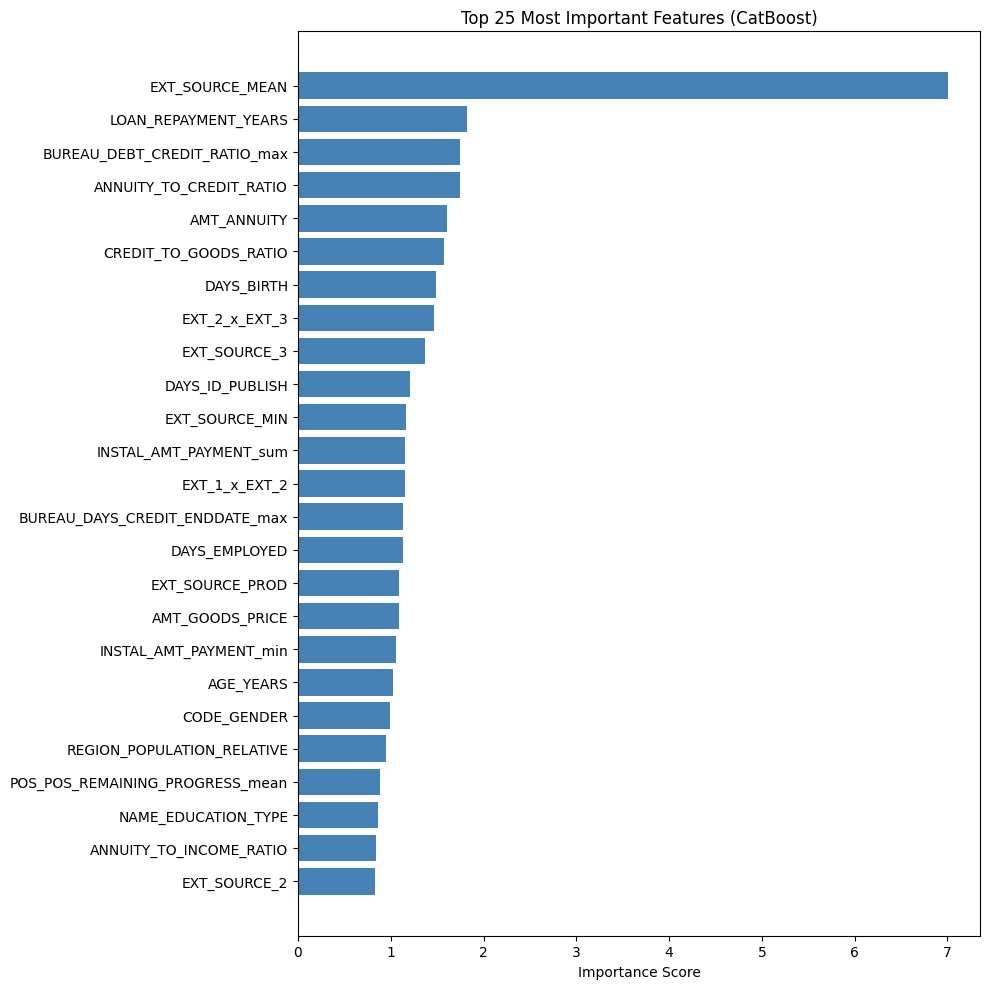

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the CatBoost model inside the pipeline
catboost_model = model.named_steps['classifier']

# Get feature names and importances
feature_names = catboost_model.feature_names_
feature_importances = catboost_model.get_feature_importance()

# Create a DataFrame and sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Show top 25
top_n = 25
top_features = importance_df.head(top_n)

print(top_features.to_string(index=False))

# Plot
plt.figure(figsize=(10, 10))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Most Important Features (CatBoost)')
plt.tight_layout()
plt.show()

In [ ]:
# Predict probabilities on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"ROC AUC Score on the test set: {auc_score:.4f}")

ROC AUC Score on the test set: 0.7927


### Generate Submission File

Now, let's load the test data, make predictions using our trained CatBoost model, and create a submission file in the format expected by the competition.

In [ ]:
# # After your first model.fit() with eval_set, extract best iteration
# best_iterations = model.named_steps['classifier'].best_iteration_

# print(f"Best iteration found: {best_iterations}")

# # Update the classifier's iterations before retraining on full data
# model.named_steps['classifier'].set_params(
#     iterations=best_iterations,
#     early_stopping_rounds=None  # Disable early stopping for final fit
# )

# model.fit(X, y)

In [ ]:
# Load the test data
df_test = test_df
display(df_test.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,HAS_BUREAU_OVERDUE,PREV_REJECTION_RATE,PREV_APPROVAL_RATE,PREV_CREDIT_TO_APPLICATION_RATIO,INSTAL_DPD_PER_PAYMENT,INSTAL_UNDERPAYMENT_RATIO,INSTAL_PAYMENT_COMPLETION_RATIO,TOTAL_DOCS_PROVIDED,TOTAL_SOCIAL_CONTACTS,REGION_RATING_MISMATCH
307511,100001,NaN,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,0.0,0.0,1.0000,0.957782,0.000267,0.000000,1.000000,1,4,0
307512,100005,NaN,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,0.0,0.0,0.2500,0.899950,0.000018,0.000000,1.000000,1,3,0
307513,100013,NaN,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,0.0,0.0,0.1875,1.116625,0.000050,0.106228,0.893772,1,3,0
307514,100028,NaN,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,0.0,0.0,0.1200,1.888340,0.000053,0.125028,0.874972,1,4,0
307515,100038,NaN,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,0.0,0.0,0.2500,1.122599,0.000000,0.000000,1.000000,1,4,0


The test set also needs the `SK_ID_CURR` column for submission, and we will make predictions for the `TARGET` column. The model pipeline will handle all the preprocessing steps defined previously (e.g., `CategoricalNaNTransformer`, `DaysEmployedAnomalyTransformer`) automatically when we call `predict_proba`.

In [ ]:
# Make predictions on the test data
# We drop SK_ID_CURR from X_test before prediction as it's not a feature.
# The pipeline expects the same columns as X_train, excluding TARGET and SK_ID_CURR if they were dropped from X_train.
y_test_pred_proba = model.predict_proba(df_test.drop(columns=['SK_ID_CURR','TARGET']))[:, 1]

# Create the submission DataFrame
submission = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET': y_test_pred_proba
})

display(submission.head())

,SK_ID_CURR,TARGET
307511,100001,0.260528
307512,100005,0.644059
307513,100013,0.219806
307514,100028,0.272633
307515,100038,0.643011


In [ ]:
# Save the submission file
submission_file_path = 'submission.csv'
submission.to_csv(submission_file_path, index=False)

print(f"Submission file '{submission_file_path}' created successfully.")

Submission file 'submission.csv' created successfully.
